#  Linear regression

In this part of this exercise, you will implement linear regression with one
variable to predict profits for a food truck. Suppose you are the CEO of a
restaurant franchise and are considering different cities for opening a new
outlet. The chain already has trucks in various cities and you have data for
profits and populations from the cities.

The file ex1data1.txt contains the dataset for our linear regression problem. The first column is the population of a city and the second column is
the profit of a food truck in that city. A negative value for profit indicates a
loss

In [1]:
from google.colab import files
uploaded = files.upload()
!ls

Saving ex1data1.txt to ex1data1.txt
ex1data1.txt  sample_data


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt('ex1data1.txt', delimiter=',')  # Load the text file with a comma as a delimiter
#load the data a create a np vectors X and y
x, y = data[:,0], data[:,1]

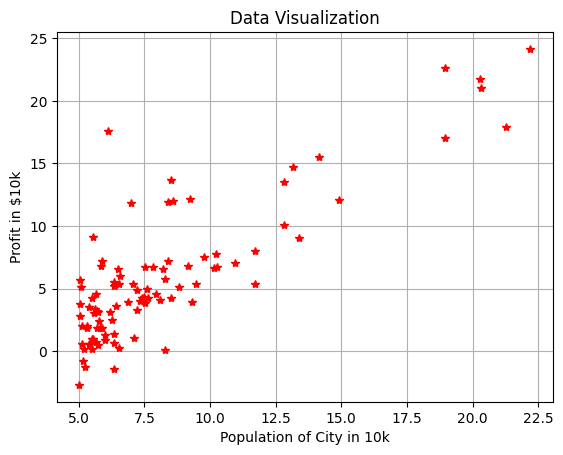

In [3]:
# ==================== Part 1: Plotting ====================
# Plot data
plt.plot(x, y, '*r', label='Profit')  # Red stars for positive examples
plt.grid(True)  # Turn on the grid
#plt.legend()    # Add legend
plt.xlabel('Population of City in 10k')  # Label for x-axis
plt.ylabel('Profit in $10k')  # Label for y-axis
plt.title('Data Visualization')  # Add a title
plt.show()

# Cost Function

The objective of linear regression is to minimize the cost function:
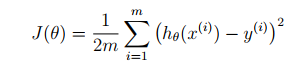

where the hypothesis h is given by

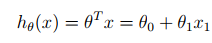

**Create a matrix by adding a column of ones to the vecto X**

You should expect to see a cost of approximately 32.07


In [9]:
# using numpy and scipy
# Sigmoid function
from scipy.optimize import minimize

#Implement cost function
def cost_function(theta, x, y):
    m = len(y)
    # Instructions: Compute the cost of a particular choice of theta
    #               You should set J to the cost.

    h = x @ theta
    E = h - y
    E_square = E.T @ E
    J = 1/(2*m) * E_square


    #J=1/(2*m)*np.sum(np.square((theta[0] + theta[1]*x) - y))
    return J.item()

m = data.shape[0]
y = data[:, [1]]
X = data[:, [0]]  # Then, create a matrix by adding a column of ones to the vecto X
X = np.hstack([np.ones((m, 1)), X])

theta = np.zeros((2, 1)) # Look that theta is a vector 2x1
iterations = 20000
alpha = 0.01
print(f"Model parameters: {theta}")
print(f"Cost function: {cost_function(theta, X, y)}") #You should expect to see a cost of approximately 32.07


Model parameters: [[0.]
 [0.]]
Cost function: 32.072733877455676


# Gradient descent

Next, you will implement gradient descent in the file gradientDescent.m.
The loop structure has been written for you, and you only need to supply
the updates to θ within each iteration.

Using the following values:
iterations = 3
theta = np.zeros((2, 1))
alpha = 0.01

The first three iteration:

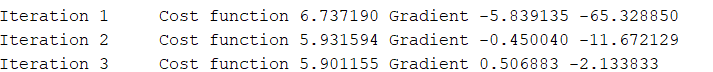



Iteration 2	Cost: 6.737190
Iteration 3	Cost: 5.931594
Iteration 4	Cost: 5.901155
Iteration 5	Cost: 5.895229
Iteration 6	Cost: 5.890095
Iteration 7	Cost: 5.885004
Iteration 8	Cost: 5.879932
Iteration 9	Cost: 5.874879
Iteration 10	Cost: 5.869844
Iteration 11	Cost: 5.864827
Iteration 12	Cost: 5.859828
Iteration 13	Cost: 5.854847
Iteration 14	Cost: 5.849884
Iteration 15	Cost: 5.844939
Iteration 16	Cost: 5.840011
Iteration 17	Cost: 5.835102
Iteration 18	Cost: 5.830210
Iteration 19	Cost: 5.825336
Iteration 20	Cost: 5.820479
Iteration 21	Cost: 5.815640
Iteration 22	Cost: 5.810818
Iteration 23	Cost: 5.806013
Iteration 24	Cost: 5.801226
Iteration 25	Cost: 5.796456
Iteration 26	Cost: 5.791704
Iteration 27	Cost: 5.786968
Iteration 28	Cost: 5.782250
Iteration 29	Cost: 5.777548
Iteration 30	Cost: 5.772863
Iteration 31	Cost: 5.768196
Iteration 32	Cost: 5.763545
Iteration 33	Cost: 5.758911
Iteration 34	Cost: 5.754293
Iteration 35	Cost: 5.749692
Iteration 36	Cost: 5.745108
Iteration 37	Cost: 5.740540


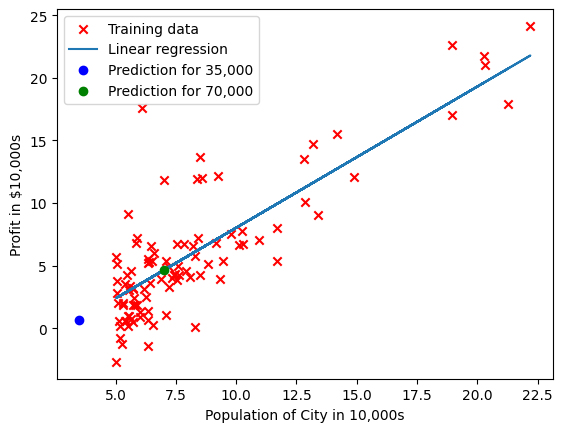

In [15]:
import numpy as np
import matplotlib.pyplot as plt
iterations = 1000
m = data.shape[0]
y = data[:, [1]]
X = data[:, [0]]
X = np.hstack([np.ones((m, 1)), X])
theta = np.zeros((2, 1))
alpha = 0.01
def gradientDescent(X, y, theta, alpha, iterations):
  m = len(y)  # number of training examples
  J_history = np.zeros(iterations)

  for iter in range(1,iterations):
  #Instructions: Perform a single gradient step on the parameter vector
  #               theta.
  #
  # Hint: While debugging, it can be useful to print out the values
  #       of the cost function (computeCostMulti) and gradient here.
      # Save the cost J in every iteration

      theta = theta - (1/m)*alpha*X.T@(X@theta - y)
      J_history[iter] = cost_function(theta,X, y)
      print(f"Iteration {iter + 1}\tCost: {J_history[iter]:.6f}")
  return theta

theta = gradientDescent(X, y, theta, alpha, iterations);
print("Theta found by gradient descent: ", theta.ravel())

# Predict values for population sizes of 35,000 and 70,000
predict1 = np.array([1, 3.5]) @ theta
print(f'For population = 35,000, we predict a profit of {(predict1 * 10000).item():.2f}')

predict2 = np.array([1, 7.0]) @ theta
print(f'For population = 35,000, we predict a profit of {(predict2 * 10000).item():.2f}')


# Plot the linear fit
plt.scatter(X[:, 1], y, color='red', marker='x', label='Training data')  # X[:,1] is the feature (since X[:,0] is the bias term)
plt.plot(X[:, 1], X @ theta, label='Linear regression')  # X @ theta gives the predicted values
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Profit in $10,000s')
plt.plot(3.5, predict1.item(), 'ob', label='Prediction for 35,000')
plt.plot(7.0, predict2.item(), 'og', label='Prediction for 70,000')
plt.legend()
plt.show()

# Visualization

Visualizing J(theta_0, theta_1) ...


<ipython-input-6-0bb2af40182e>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_vals[i, j] = cost_function(t, X, y)


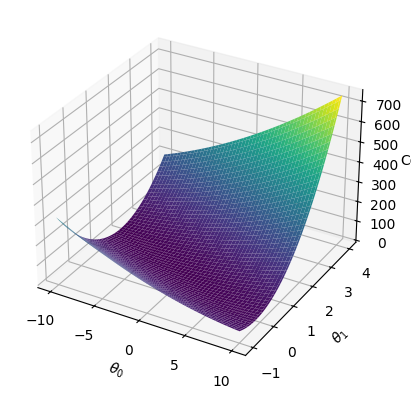

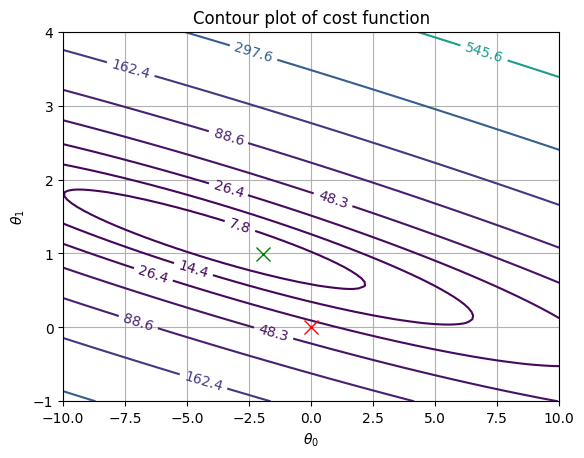

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots

print('Visualizing J(theta_0, theta_1) ...')

theta_init = np.zeros((2, 1))
# Grid over which we will calculate J
theta0_vals = np.linspace(-10, 10, 100)
theta1_vals = np.linspace(-1, 4, 100)

# Initialize J_vals to a matrix of 0's
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

# Fill out J_vals
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        t = np.array([[theta0_vals[i]], [theta1_vals[j]]])
        J_vals[i, j] = cost_function(t, X, y)

# Transpose J_vals to match the orientation of MATLAB's surf
J_vals = J_vals.T

# Surface plot
theta0_vals_mesh, theta1_vals_mesh = np.meshgrid(theta0_vals, theta1_vals)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta0_vals_mesh, theta1_vals_mesh, J_vals, cmap='viridis')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('Cost')

# Contour plot
plt.figure()
cp = plt.contour(theta0_vals, theta1_vals, J_vals, levels=np.logspace(-2, 3, 20))
plt.clabel(cp)
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')

# Plot the final theta found by gradient descent
plt.plot(theta_init[0, 0], theta_init[1, 0], 'rx', markersize=10, linewidth=2)
plt.plot(theta[0, 0], theta[1, 0], 'gx', markersize=10, linewidth=2)
plt.title('Contour plot of cost function')
plt.grid(True)
plt.show()
